In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("default")

In [2]:
df = pd.read_csv("customer_features.csv")
df.head()

,customer_unique_id,customer_city,customer_state,total_orders,repeat_customer,total_spent,average_order_value,median_order_value,minimum_order_value,maximum_order_value,...,recency,customer_lifetime_days,customer_age,weekend_purchase_percentage,average_item_price,freight_percentage,purchase_frequency,category_diversity_ratio,low_review_orders,high_review_orders
0,df3bcbcb88d40ad1996ad1325fe8f481,praia grande,SP,1,0,160.28,160.28,160.28,160.28,160.28,...,124,0,124,0.0,80.14,14.349888,inf,0.5,0,1
1,58704dbb44acbec0448a215ac2871320,sao paulo,SP,1,0,70.72,70.72,70.72,70.72,70.72,...,379,0,379,0.0,70.72,16.586538,inf,1.0,0,1
2,e06358b52b33afa8edfe5a0664cfe9c5,ponte serrada,SC,1,0,60.10,60.10,60.10,60.10,60.10,...,240,0,240,0.0,60.10,25.124792,inf,1.0,1,0
3,ee66c72bc9c41ae9de8260314b8088f4,juiz de fora,MG,1,0,247.36,247.36,247.36,247.36,247.36,...,119,0,119,0.0,123.68,19.154269,inf,0.5,0,1
4,c2e79de2c0a7751e26564a3917f9e86d,sao paulo,SP,1,0,115.44,115.44,115.44,115.44,115.44,...,504,0,504,0.0,115.44,13.383576,inf,1.0,0,1


In [3]:
df.columns.tolist()

['customer_unique_id',
 'customer_city',
 'customer_state',
 'total_orders',
 'repeat_customer',
 'total_spent',
 'average_order_value',
 'median_order_value',
 'minimum_order_value',
 'maximum_order_value',
 'spend_std_dev',
 'total_items',
 'average_basket_size',
 'largest_basket',
 'total_unique_products',
 'total_categories',
 'total_freight',
 'average_freight',
 'average_review',
 'minimum_review',
 'maximum_review',
 'review_std_dev',
 'average_installments',
 'maximum_installments',
 'payment_methods_used',
 'average_delivery_days',
 'average_delivery_delay',
 'first_purchase',
 'last_purchase',
 'recency',
 'customer_lifetime_days',
 'customer_age',
 'weekend_purchase_percentage',
 'average_item_price',
 'freight_percentage',
 'purchase_frequency',
 'category_diversity_ratio',
 'low_review_orders',
 'high_review_orders']

In [4]:
rfm = df[
    [
        "customer_unique_id",
        "recency",
        "total_orders",
        "total_spent"
    ]
].copy()
rfm.head()

,customer_unique_id,recency,total_orders,total_spent
0,df3bcbcb88d40ad1996ad1325fe8f481,124,1,160.28
1,58704dbb44acbec0448a215ac2871320,379,1,70.72
2,e06358b52b33afa8edfe5a0664cfe9c5,240,1,60.10
3,ee66c72bc9c41ae9de8260314b8088f4,119,1,247.36
4,c2e79de2c0a7751e26564a3917f9e86d,504,1,115.44


In [5]:
rfm.isnull().sum()

customer_unique_id    0
recency               0
total_orders          0
total_spent           1
dtype: int64

In [6]:
rfm = rfm.dropna()

In [7]:
rfm.columns = [
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary"
]

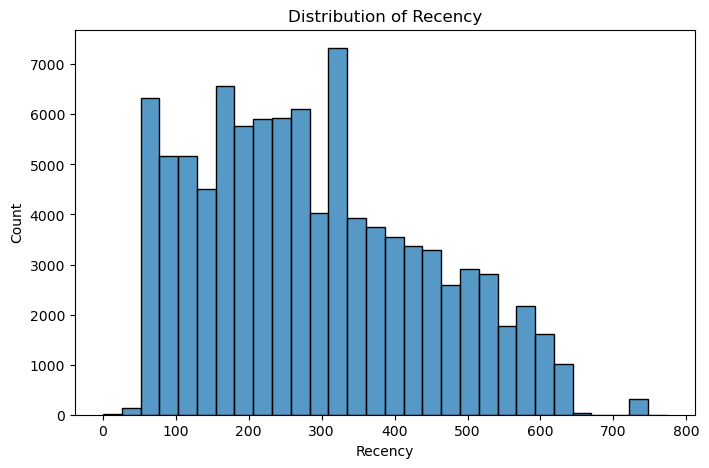

In [8]:
#Distribution of RFM Variables
plt.figure(figsize=(8,5))

sns.histplot(
    rfm["Recency"],
    bins=30,
    kde=False
)
plt.title("Distribution of Recency")
plt.show()

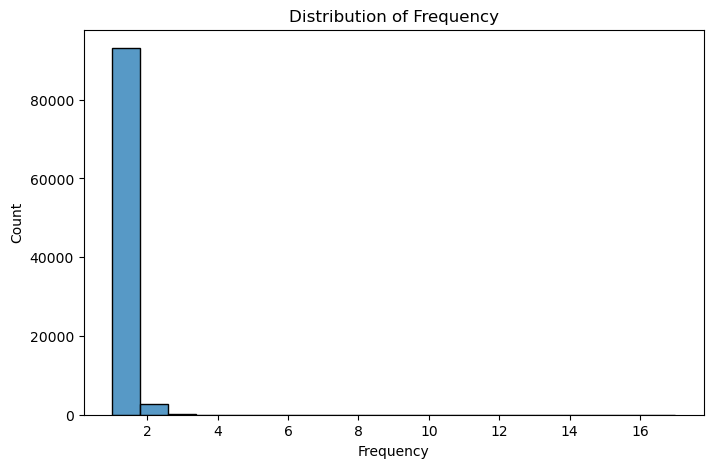

In [9]:
#Frequency
plt.figure(figsize=(8,5))

sns.histplot(
    rfm["Frequency"],
    bins=20,
    kde=False
)
plt.title("Distribution of Frequency")
plt.show()

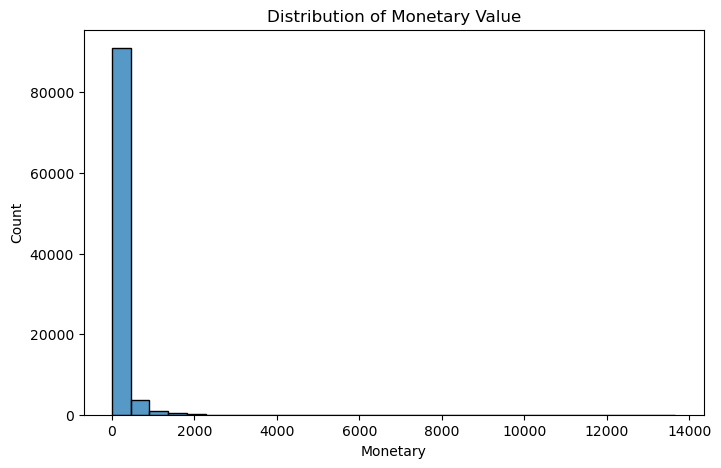

In [10]:
#Monetary
plt.figure(figsize=(8,5))
sns.histplot(
    rfm["Monetary"],
    bins=30,
    kde=False
)
plt.title("Distribution of Monetary Value")
plt.show()

In [11]:
#Create RFM Scores
#Recency Score
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
).astype(int)

In [12]:
#Frequency Score
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
).astype(int)

In [13]:
#Monetary Score
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
).astype(int)

In [14]:
#Overall RFM Score
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,df3bcbcb88d40ad1996ad1325fe8f481,124,1,160.28,5,1,4,514
1,58704dbb44acbec0448a215ac2871320,379,1,70.72,2,1,2,212
2,e06358b52b33afa8edfe5a0664cfe9c5,240,1,60.10,3,1,2,312
3,ee66c72bc9c41ae9de8260314b8088f4,119,1,247.36,5,1,5,515
4,c2e79de2c0a7751e26564a3917f9e86d,504,1,115.44,1,1,3,113


In [15]:
#Total RFM Score
rfm["Total_RFM"] = (
    rfm["R_Score"] +
    rfm["F_Score"] +
    rfm["M_Score"]
)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Total_RFM
0,df3bcbcb88d40ad1996ad1325fe8f481,124,1,160.28,5,1,4,514,10
1,58704dbb44acbec0448a215ac2871320,379,1,70.72,2,1,2,212,5
2,e06358b52b33afa8edfe5a0664cfe9c5,240,1,60.10,3,1,2,312,6
3,ee66c72bc9c41ae9de8260314b8088f4,119,1,247.36,5,1,5,515,11
4,c2e79de2c0a7751e26564a3917f9e86d,504,1,115.44,1,1,3,113,5


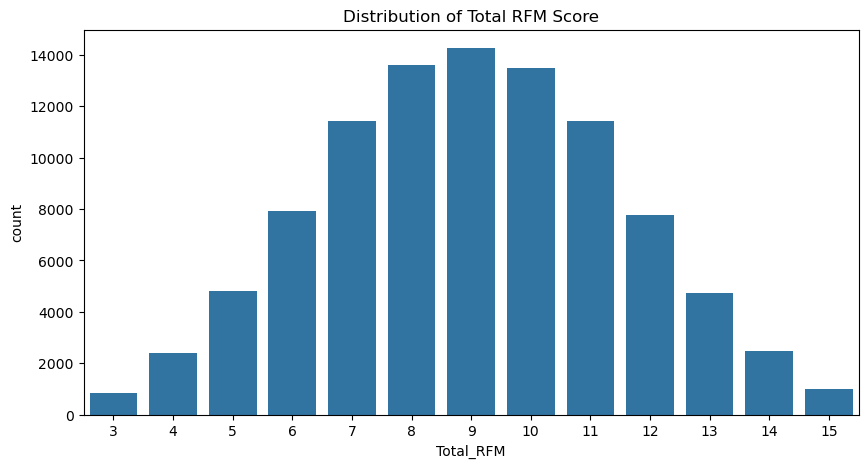

In [16]:
#Distribution of Total Scores
plt.figure(figsize=(10,5))

sns.countplot(
    data=rfm,
    x="Total_RFM"
)
plt.title("Distribution of Total RFM Score")
plt.show()

In [17]:
def segment(row):

    R = row["R_Score"]
    F = row["F_Score"]
    M = row["M_Score"]

    if R >= 4 and F >= 4:
        return "Champions"

    elif R >= 3 and F >= 3:
        return "Loyal Customers"

    elif R >= 4 and F <= 2:
        return "Potential Loyalists"

    elif R <= 2 and (F >= 3 or M >= 3):
        return "At Risk"

    else:
        return "Lost Customers"

In [18]:
rfm["Segment"] = rfm.apply(segment, axis=1)

In [19]:
#Segment Counts
rfm["Segment"].value_counts()

Segment
At Risk                31773
Loyal Customers        19307
Champions              15506
Potential Loyalists    15309
Lost Customers         14200
Name: count, dtype: int64

In [20]:
#Segment Percentages
(
    rfm["Segment"]
    .value_counts(normalize=True)
    *100
).round(2)

Segment
At Risk                33.06
Loyal Customers        20.09
Champions              16.14
Potential Loyalists    15.93
Lost Customers         14.78
Name: proportion, dtype: float64

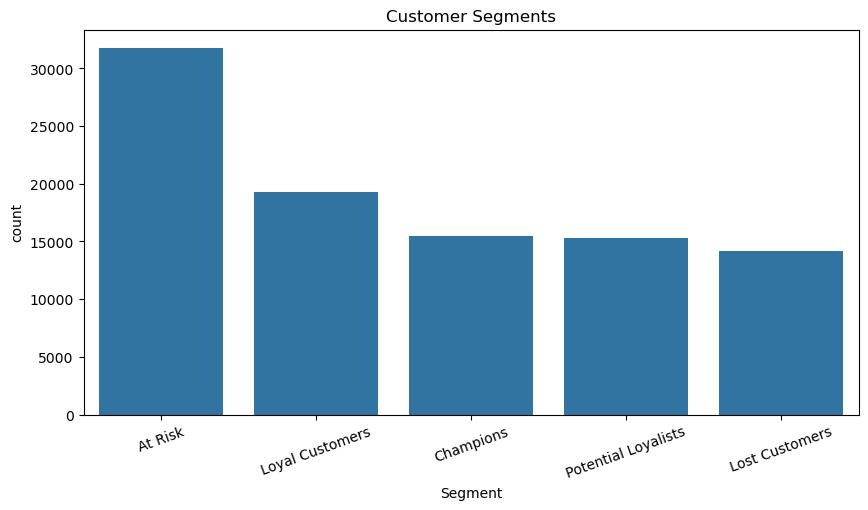

In [21]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=rfm,
    x="Segment",
    order=rfm["Segment"].value_counts().index
)
plt.xticks(rotation=20)
plt.title("Customer Segments")
plt.show()

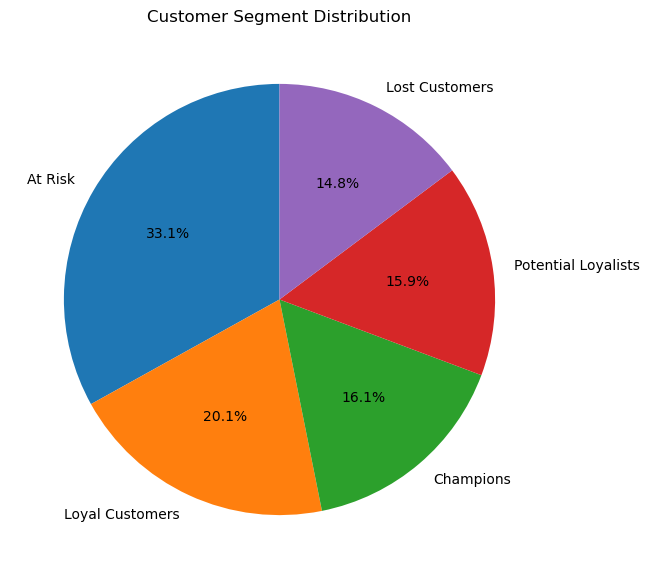

In [22]:
segment_counts = rfm["Segment"].value_counts()
plt.figure(figsize=(7,7))
plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Customer Segment Distribution")
plt.show()

In [23]:
#Average RFM Values by Segment
segment_summary = (
    rfm
    .groupby("Segment")[["Recency","Frequency","Monetary"]]
    .mean()
    .round(2)
)
segment_summary

,Recency,Frequency,Monetary
Segment,,,
At Risk,445.53,1.04,187.83
Champions,140.41,1.10,177.34
Lost Customers,352.48,1.00,106.91
Loyal Customers,217.90,1.04,159.67
Potential Loyalists,139.80,1.00,165.87


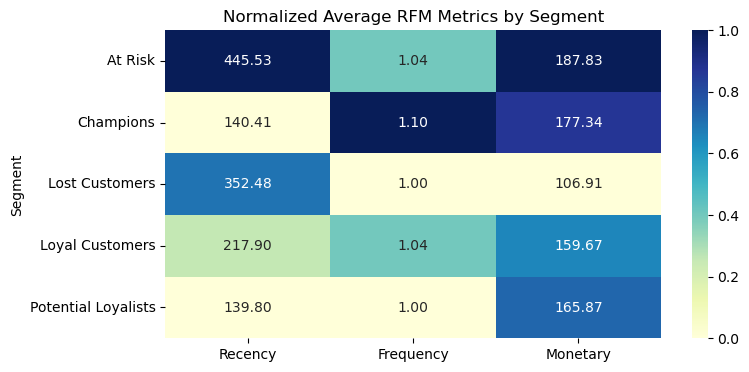

In [24]:
from sklearn.preprocessing import MinMaxScaler
scaled_summary = pd.DataFrame(
    MinMaxScaler().fit_transform(segment_summary),
    columns=segment_summary.columns,
    index=segment_summary.index
)
plt.figure(figsize=(8,4))
sns.heatmap(
    scaled_summary,
    annot=segment_summary.round(2),   # show original values
    fmt=".2f",
    cmap="YlGnBu"
)
plt.title("Normalized Average RFM Metrics by Segment")
plt.show()

1) Champions have the lowest recency (140 days), highest purchase frequency (1.10), and high monetary value (175.24), making them the most valuable customer segment.

2) Loyal Customers exhibit moderate recency (219 days) and high spending (161.87), indicating strong revenue potential and the need for retention initiatives.

3) Potential Loyalists have recent purchases (140 days) but lower purchase frequency (1.00), suggesting an opportunity to convert them into repeat buyers through personalized offers.

4) At Risk customers have the highest recency (446 days) despite relatively high spending (188.03), indicating previously valuable customers who require targeted win-back campaigns.

5) Lost Customers have high recency (353 days), lowest purchase frequency (1.00), and lowest monetary value (107.70), making them the least engaged segment.

##### Summary
Recency and Monetary value are the primary drivers of customer segmentation, while Frequency shows minimal variation because most Olist customers make only a single purchase. This suggests that improving customer retention and encouraging repeat purchases should be the primary business strategy.